# Setup  

In [1]:
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.6.0-4.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
!pip install "rpy2[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.7 MB/s eta 0:00:00


In [3]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

In [4]:
%load_ext rpy2.ipython

In [5]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packages = ["lcmm"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpsmiJ4O/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7bc8bb4549d0> [0]

In [6]:
!pip install -U scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 42.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [7]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [8]:
%%R
R.version.string

[1] "R version 4.6.0 (2026-04-24)"


In [9]:
!python --version

Python 3.12.13


In [10]:
drive.mount('/content/drive')

df_curated = pd.read_excel("/content/drive/MyDrive/data/PPMI_Curated_Data_Cut_Public_20260223.xlsx")

df_vital = pd.read_csv("/content/drive/MyDrive/data/Vital_Signs_21Mar2026.csv")

df_mri = pd.read_csv("/content/drive/MyDrive/data/mri_vol_and_cth_norm_averaged.csv")

Mounted at /content/drive


# Inclusion criteria   


In [11]:
curated = df_curated[[
    # ID
    "PATNO",
    "COHORT",
    "EVENT_ID",

    # time variable
    "YEAR", # visit year, derived from EVENT_ID, numeric
    "visit_date", # Month and Year of Clinical Visit (Note: Collection dates of DATSCAN, lumbar puncture, or other imaging/lab data may be different.)

    # sleep
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    # autonomic dysfunction
    "scopa", # SCOPA-AUT Total Score
    # psychiatric
    "stai", #State-Trait Anxiety Index (STAI) Total Score
    # cognitive
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected), DVT_SDM = 10*SD + 50, where SD is derived as above
    # motor
    "updrs3_score", # Score is based on values taken when participant is either "OFF" PD medication or untreated for PD

    # demo & clinical
    "SEX",
    "EDUCYRS", #Years of Education capped at 20
    "age", # age at enrollment
    "fampd_bin",  # Family History of PD - Binary, 1 Any Family w/PD, 2 No Family w/PD
    "LEDD", # Total Levodopa Equivalent Daily Dose
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "hy", # Reclassified Hoehn & Yahr Stage (includes OFF and untreated scores)
    "ageonset",
    "subgroup",
    "moca",
    "gds",
    "stai_state",
    "stai_trait",
    "pigd",
    "COG_COMPOSITE_INT",
    "COG_COMPOSITE_EXT",
    "td_pigd",
    "ess",
    "MSEADLG",
    "upsit_pctl15",
    "cogstate",
    "age_at_visit",
    'MIA_CAUDATE_L', 'MIA_CAUDATE_R', 'MIA_CAUDATE_BILAT',
    'MIA_PUTAMEN_L', 'MIA_PUTAMEN_R', 'MIA_PUTAMEN_BILAT',
    'MIA_STRIATUM_L', 'MIA_STRIATUM_R', 'MIA_STRIATUM_BILAT'
]].copy()

In [12]:
vs = df_vital[[
    "PATNO",
    "EVENT_ID",
    "SYSSUP",   # Supine BP - systolic (mmHg)
    "SYSSTND"    # Standing BP - systolic (mmHg)
]].copy()

In [13]:
df = curated.merge(
    vs,
    on=["PATNO", "EVENT_ID"],
    how="left",
    validate="one_to_one"
)

In [14]:
df["delta_sbp"] = df["SYSSUP"] - df["SYSSTND"]
df["delta_sbp"].describe()

,delta_sbp
count,17203.000000
mean,4.076731
std,13.370832
min,-77.000000
25%,-4.000000
50%,3.000000
75%,11.000000
max,111.000000


(-50.0, 100.0)

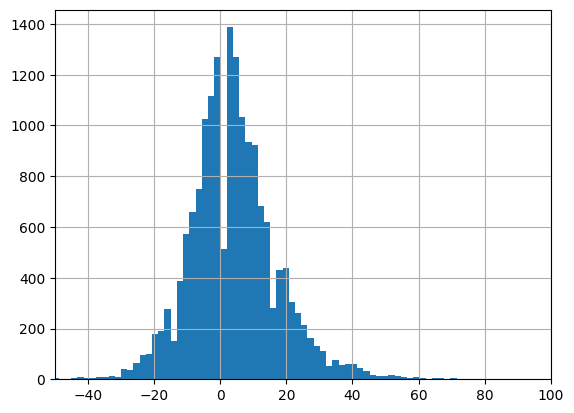

In [15]:
df["delta_sbp"].hist(bins=100)
plt.xlim(-50, 100)

In [16]:
df_pd = df[df["COHORT"] == 1].copy()

In [17]:
bl_pd = df_pd[df_pd["YEAR"] == 0].copy()

In [18]:
# boolean series
mask = (
    (bl_pd["ageonset"] >= 50) &
    (bl_pd["duration_yrs"] <=2) &
    (bl_pd["LEDD"] == 0) &
    (bl_pd["hy"] != 3) &
    (bl_pd["cogstate"] != 3)
)

ids = bl_pd.loc[mask, "PATNO"].dropna().unique()
print(len(ids))

919


In [19]:
df_pd = df_pd[df_pd["PATNO"].isin(ids)].copy()

In [20]:
visit_counts = df_pd.groupby("PATNO")["YEAR"].nunique()
ids_2plus = visit_counts[visit_counts >=2].index
df_pd_final = df_pd[df_pd["PATNO"].isin(ids_2plus)].copy()

In [21]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 4542
YEAR range: 0 15
count    855.000000
mean       5.312281
std        3.653560
min        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       15.000000
Name: YEAR, dtype: float64
YEAR
0     855
1     828
2     671
3     481
4     330
5     244
6     209
7     184
8     130
9     122
10    136
11    128
12    120
13     79
14     23
15      2
Name: PATNO, dtype: int64


In [22]:
df_pd_final = df_pd_final[df_pd_final["YEAR"] <= 5].copy()

In [23]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 3409
YEAR range: 0 5
count    855.000000
mean       3.987135
std        1.491921
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        6.000000
Name: YEAR, dtype: float64
YEAR
0    855
1    828
2    671
3    481
4    330
5    244
Name: PATNO, dtype: int64


In [24]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

# MCAR

In [ ]:
packages = ["MissMech", "naniar"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpFBXNwH/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7cd5f790d7d0> [0]

In [ ]:
%%R -i df
library(naniar)

dat <- as.data.frame(df)

vars_mcar <- c("rem", "moca", "updrs3_score", "delta_sbp")
dat_mcar <- dat[, vars_mcar]

mcar_test(dat_mcar)

# A tibble: 1 × 4
  statistic    df p.value missing.patterns
      <dbl> <dbl>   <dbl>            <int>
1      208.    28       0               16


# missing pattern

In [ ]:
packages = ["VIM"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)





























































	‘/tmp/RtmpFBXNwH/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7cd5f790d7d0> [0]


 Variables sorted by number of missings: 
     Variable       Count
 updrs3_score 0.159870930
    delta_sbp 0.029920798
         moca 0.010853623
          rem 0.008800235


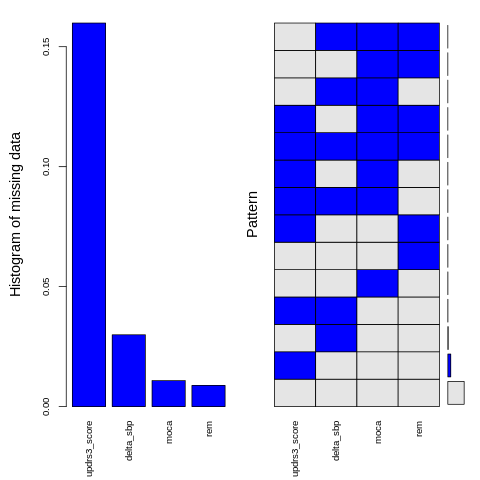

In [ ]:
%%R
library(VIM)

vars <- df[, c(
  "rem", "moca", "updrs3_score", "delta_sbp"
)]

aggr(
  vars,
  col = c("grey90", "blue"),
  numbers = FALSE,
  sortVars = TRUE,
  labels = names(vars),
  cex.axis = 0.8,
  gap = 3,
  ylab = c("Histogram of missing data", "Pattern")
)

# multlcmm, random=~1, zscore(moca_transform), linear

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/final/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   173      0.202 0.868 26.0 
2     2   568      0.664 0.922  5.98
3     3   114      0.133 0.787 24.0 


# baseline characteristic

## add variables

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations


pp = pd.read_csv(
    "/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv"
)[["PATNO", "class"]]

pp["PATNO"] = pd.to_numeric(pp["PATNO"], errors="coerce")


base_curated = df_curated[df_curated["YEAR"] == 0].copy()
base_curated["PATNO"] = pd.to_numeric(base_curated["PATNO"], errors="coerce")



base_sbp = (
    df_pd_final.loc[df_pd_final["YEAR"] == 0, ["PATNO", "delta_sbp"]] #+ expected_ratio_cols]
    .drop_duplicates(subset="PATNO")
    .copy()
)

base_sbp["PATNO"] = pd.to_numeric(base_sbp["PATNO"], errors="coerce")


df_mri["PATNO"] = pd.to_numeric(df_mri["PATNO"], errors="coerce")


df_base = base_curated.merge(base_sbp, on="PATNO", how="left", suffixes=("", "_sbp"))
df_base = df_base.merge(pp, on="PATNO", how="inner")
df_base = df_base.merge(df_mri, on="PATNO", how="left")
df_base = df_base.drop_duplicates(subset="PATNO").copy()


csf_num = pd.to_numeric(df_base["CSFSAA"], errors="coerce")
df_base["CSFSAA_bl"] = np.where(csf_num.isna(), np.nan, np.where(csf_num == 1, 1.0, 0.0))


print("rows:", len(df_base))
print("unique PATNO:", df_base["PATNO"].nunique())
print("duplicated PATNO:", df_base["PATNO"].duplicated().sum())
print("\nclass counts:")
print(df_base["class"].value_counts(dropna=False).sort_index())


mri_vars = [
    c for c in df_mri.columns
    if c != "PATNO"
]


vars_cont = [
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    "moca",# Montreal Cognitive Assessment (MoCA) Score (adjusted for education)
    "updrs3_score", # MDS-UPDRS Part III Score OFF (includes OFF and untreated scores)
    "delta_sbp",
    "agediag", # Age at PD Diagnosis
    "ageonset",
    "EDUCYRS", # Years of Education capped at 20
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "upsit", # UPSIT Raw Score
    "upsit_pctl",
    "scopa", # SCOPA-AUT Total Score
    "stai", # State-Trait Anxiety Index (STAI) Total Score
    "gds", # Geriatric Depression Scale Score
    "ess", # Epworth Sleepiness Scale Score
    "quip", # Questionnaire for Impulsive-Compulsive Disorders in PD (QUIP) Score
    "DVT_CLCKDRAW", # Clock Drawing Test t-score (age-corrected)
    "DVT_TOTAL_RECALL", # HVLT Immediate/Total Recall t-score
    "DVT_DELAYED_RECALL",# HVLT Delayed Recall t-score
    "DVT_RETENTION", # HVLT Retention t-score
    "DVT_FAS", # Lexical Fluency letter (FAS) t-score (age- and education-corrected)
    "DVS_JLO_MSSAE",#Benton Judgment of Line Orientation MOANS Scaled Score (age- and education-corrected)
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected)
    "DVS_LNS", # Letter Number Sequencing Scaled Score (age-corrected)
    "DVS_BNT",
    "MSEADLG", # Modified Schwab & England Activities of Daily Living Score
    "pigd", # PIGD OFF score (includes OFF and untreated scores)
    "updrs1_score", # MDS-UPDRS Part I Score
    "updrs2_score", # MDS-UPDRS Part II Score
    "updrs_totscore", # MDS-UPDRS Total Score OFF (includes OFF and untreated scores)
    "MIA_LOWPUT_EXPECTED",
    "APOE",
    "APOE_e4",
    "abeta",
    "asyn",
    "ptau",
    "tau",
    "urate",
    "nfl_csf",
    "nfl_serum"
]


vars_cont = vars_cont + mri_vars


vars_cat_binary = [
    "SEX", # 1 male
    "CSFSAA_bl",
]


vars_cat_multi = [
    "DOMSIDE", # Side most affected at PD symptom onset 1 left 2 right 3 symmetric
    "NHY", # Hoehn & Yahr Stage (includes OFF and untreated scores)
    "cogstate", # Investigator Diagnosis of Cognitive State 1 Normal cognition 2 Mild cognitive impairment 3 Dementia
    "CSFSAA"
]


rows: 855
unique PATNO: 855
duplicated PATNO: 0

class counts:
class
1    173
2    568
3    114
Name: count, dtype: int64


## add scipy.stats.fisher_exact

In [26]:
!pip install scikit-posthocs

In [27]:
import os
import numpy as np
import pandas as pd

from itertools import combinations

from scipy.stats import (
    kruskal,
    chi2_contingency,
    fisher_exact,
    MonteCarloMethod,   # scipy >= 1.15
)

from statsmodels.stats.multitest import multipletests

import scikit_posthocs as sp


out_dir = "/content/drive/MyDrive/data/"
os.makedirs(out_dir, exist_ok=True)

# Keep only variables that actually exist in df_base to avoid errors from misspelled names
vars_cont = [v for v in vars_cont if v in df_base.columns]
vars_cat_binary = [v for v in vars_cat_binary if v in df_base.columns]
vars_cat_multi = [v for v in vars_cat_multi if v in df_base.columns]


# Continuous variables: remove all-missing or constant variables, which cannot be tested
vars_cont_use = []
dropped_constant_cont = []
for var in vars_cont:
    sub = pd.to_numeric(df_base[var], errors="coerce").dropna()
    if len(sub) == 0:
        dropped_constant_cont.append((var, "all missing"))
        continue
    if sub.nunique() <= 1:
        dropped_constant_cont.append((var, f"constant: {sub.iloc[0]}"))
        continue
    vars_cont_use.append(var)

print("\nContinuous vars used:", vars_cont_use)
print("\nDropped constant/all-missing continuous vars:", dropped_constant_cont)
print("\nBinary categorical vars:", vars_cat_binary)
print("\nMulti categorical vars:", vars_cat_multi)


# Formatting functions for descriptive statistics
def mean_sd(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return ""
    return f"{x.mean():.5f} ({x.std():.5f})"

def n_pct_binary(x, positive=1):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return ""
    n = (x == positive).sum()
    pct = n / len(x) * 100
    return f"{n} ({pct:.2f})"

def fmt_p(p):
    p = pd.to_numeric(pd.Series([p]), errors="coerce").iloc[0]
    if pd.isna(p):
        return ""
    elif p < 0.0001:
        return "<0.0001"
    elif p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"


# Count available non-missing observations by class
def n_available_by_class(df, var, class_col="class"):
    if var not in df.columns:
        return {}
    s = df[[class_col, var]].copy()
    s[var] = s[var].replace("", np.nan)
    s = s.dropna(subset=[var])
    return s.groupby(class_col)[var].size().to_dict()


# Continuous variables: overall Kruskal-Wallis + pairwise Dunn tests
def kruskal_p(df, var, class_col="class"):
    if var not in df.columns:
        return np.nan
    sub = df[[class_col, var]].copy()
    sub[var] = pd.to_numeric(sub[var], errors="coerce")
    sub = sub.dropna()
    groups = sorted(sub[class_col].unique())
    if len(groups) < 2:
        return np.nan
    samples = [sub.loc[sub[class_col] == g, var] for g in groups]
    if any(len(s) == 0 for s in samples):
        return np.nan
    all_vals = np.concatenate([np.array(s) for s in samples if len(s) > 0])
    if len(np.unique(all_vals)) <= 1:   # All values are identical, so the test cannot be performed
        return np.nan
    try:
        return kruskal(*samples).pvalue
    except ValueError:
        return np.nan


def pairwise_cont_p(df, var, class_col="class"):
    """Pairwise comparison for continuous variables: Dunn test with internal FDR adjustment."""
    try:
        dunn_res = sp.posthoc_dunn(df, val_col=var, group_col=class_col, p_adjust="fdr_bh")
        labels = list(dunn_res.index)
        def _get(a, b):
            return dunn_res.loc[a, b] if (a in labels and b in labels) else np.nan
        return {"1_vs_2": _get(1, 2),
                "1_vs_3": _get(1, 3),
                "2_vs_3": _get(2, 3)}
    except Exception as e:
        print(f"[pairwise_cont_p] {var} failed: {e!r}")
        return {"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan}


# Categorical tests: automatically switch to exact tests for sparse tables
def _need_exact(expected):
    """Cochran rule: any expected count < 1, or >20% of cells with expected counts < 5 -> use an exact test."""
    expected = np.asarray(expected, dtype=float)
    return bool((expected < 1).any() or (expected < 5).mean() > 0.2)


def _rc_fisher_mc_p(tab, n_iter=100000, seed=0):
    """
    R×C contingency table: official Fisher's exact test with Monte Carlo simulation
    (requires scipy >= 1.15).
    The row and column margins are fixed, and the p-value is estimated by sampling
    from random_table.
    """
    tab = np.asarray(tab)
    if tab.ndim != 2 or tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    if np.any(tab < 0):
        return np.nan
    tab = np.rint(tab).astype(int)
    if tab.sum() == 0:
        return np.nan
    try:
        method = MonteCarloMethod(n_resamples=n_iter, rng=np.random.default_rng(seed))
        return fisher_exact(tab, method=method).pvalue
    except TypeError:
        method = MonteCarloMethod(n_resamples=n_iter)
        return fisher_exact(tab, method=method).pvalue
    except Exception as e:
        print(f"[_rc_fisher_mc_p] failed: {e!r}")
        return np.nan


def _table_test(tab, exact_iter=100000, seed=0):
    """Select the appropriate test for a crosstab and return (test_name, p)."""
    tab_values = np.asarray(tab.values if hasattr(tab, "values") else tab)
    tab_values = np.rint(tab_values).astype(int)
    if tab_values.shape[0] < 2 or tab_values.shape[1] < 2:
        return None, np.nan
    try:
        # Run the chi-square test to obtain the chi-square p-value and expected counts
        # Use the default correction=True to keep results consistent with the previous output
        chi2, p_chi, dof, expected = chi2_contingency(tab_values)
    except Exception as e:
        print(f"[_table_test] chi-square failed: {e!r}")
        return None, np.nan

    if not _need_exact(expected):
        return "Chi-square", p_chi

    # Sparse 2×2 table: standard Fisher's exact test
    if tab_values.shape == (2, 2):
        try:
            _, p = fisher_exact(tab_values)
            return "Fisher exact", p
        except Exception as e:
            print(f"[_table_test] Fisher 2x2 failed: {e!r}")
            return None, np.nan

    # Sparse R×C table: official Monte Carlo Fisher's exact test
    p = _rc_fisher_mc_p(tab_values, n_iter=exact_iter, seed=seed)
    return "Fisher exact MC", p


def chisq_test(df, var, class_col="class"):
    """Overall test for categorical variables."""
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()
    if sub.empty:
        return None, np.nan
    tab = pd.crosstab(sub[class_col], sub[var])
    return _table_test(tab)


def pairwise_cat_p(df, var, class_col="class"):
    """Pairwise comparison for categorical variables, with FDR adjustment within each variable."""
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()
    groups = sorted(sub[class_col].unique())
    out_raw = {}
    for g1, g2 in combinations(groups, 2):
        key = f"{g1}_vs_{g2}"
        sub2 = sub[sub[class_col].isin([g1, g2])]
        tab = pd.crosstab(sub2[class_col], sub2[var])
        if tab.shape[0] < 2 or tab.shape[1] < 2:
            out_raw[key] = np.nan
            continue
        try:
            _, p = _table_test(tab)
            out_raw[key] = p
        except Exception as e:
            print(f"[pairwise_cat_p] {var} {key} failed: {e!r}")
            out_raw[key] = np.nan
    keys = ["1_vs_2", "1_vs_3", "2_vs_3"]
    for k in keys:
        out_raw.setdefault(k, np.nan)
    vals = np.array([out_raw[k] for k in keys], dtype=float)
    mask = ~np.isnan(vals)
    vals_adj = np.full(len(vals), np.nan)
    if mask.sum() > 0:
        vals_adj[mask] = multipletests(vals[mask], method="fdr_bh")[1]
    return dict(zip(keys, vals_adj))

# Display for multi-category variables

def build_multicat_rows(df, var, class_col="class"):
    """Multi-category variables: one row per level, showing n (%) for each class."""
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()
    if sub.empty:
        return pd.DataFrame(columns=["variable"])
    try:
        levels = sorted(sub[var].dropna().unique(), key=lambda x: float(x))
    except Exception:
        levels = sorted(sub[var].dropna().unique())
    groups = sorted(sub[class_col].unique())
    out_rows = []
    for level in levels:
        row = {"variable": f"{var}={level}"}
        for g in groups:
            xg = sub.loc[sub[class_col] == g, var]
            n_total = len(xg)
            n_level = (xg == level).sum()
            pct = (n_level / n_total * 100) if n_total > 0 else np.nan
            row[f"class_{g}"] = f"{n_level} ({pct:.1f})" if n_total > 0 else ""
        out_rows.append(row)
    return pd.DataFrame(out_rows)


# Continuous variables: descriptive statistics + tests
if len(vars_cont_use) > 0:
    table_cont = df_base.groupby("class")[vars_cont_use].agg(mean_sd).T
    table_cont.columns = [f"class_{c}" for c in table_cont.columns]
    table_cont.index.name = "variable"
else:
    table_cont = pd.DataFrame()

cont_results = []
for var in vars_cont_use:
    p_overall = kruskal_p(df_base, var)
    row = {"variable": var, "test": "Kruskal-Wallis", "p_overall": p_overall}
    if pd.notna(p_overall):
        row.update(pairwise_cont_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})
    cont_results.append(row)

cont_results = pd.DataFrame(cont_results)
if len(cont_results) > 0:
    cont_results = cont_results.set_index("variable")
    table_cont = table_cont.join(cont_results, how="left")
else:
    cont_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])



# Binary categorical variables: descriptive statistics + tests
if len(vars_cat_binary) > 0:
    table_cat_binary = df_base.groupby("class")[vars_cat_binary].agg(n_pct_binary).T
    table_cat_binary.columns = [f"class_{c}" for c in table_cat_binary.columns]
    table_cat_binary.index.name = "variable"
else:
    table_cat_binary = pd.DataFrame()

cat_binary_results = []
for var in vars_cat_binary:
    test_name, p = chisq_test(df_base, var)
    row = {"variable": var, "test": test_name, "p_overall": p}
    if pd.notna(p):
        row.update(pairwise_cat_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})
    cat_binary_results.append(row)

cat_binary_results = pd.DataFrame(cat_binary_results)
if len(cat_binary_results) > 0:
    cat_binary_results = cat_binary_results.set_index("variable")
    table_cat_binary = table_cat_binary.join(cat_binary_results, how="left")
else:
    cat_binary_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])



# Multi-category variables: one row per level with n (%); test results are written to the first row
multi_tables = []
cat_multi_results = []
for var in vars_cat_multi:
    tmp = build_multicat_rows(df_base, var)
    if len(tmp) > 0:
        multi_tables.append(tmp)
    test_name, p = chisq_test(df_base, var)
    row = {"variable": var, "test": test_name, "p_overall": p}
    if pd.notna(p):
        row.update(pairwise_cat_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})
    cat_multi_results.append(row)

if len(multi_tables) > 0:
    table_cat_multi = pd.concat(multi_tables, axis=0).set_index("variable")
else:
    table_cat_multi = pd.DataFrame()

cat_multi_results = pd.DataFrame(cat_multi_results)
if len(cat_multi_results) > 0:
    cat_multi_results = cat_multi_results.set_index("variable")
else:
    cat_multi_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])



# Concatenate all per-variable results (used for the saved statistics summary)
all_results = pd.concat([cont_results, cat_binary_results, cat_multi_results], axis=0)


# Multi-category variables: write each variable's test/p-values to its first level row
for var in vars_cat_multi:
    rows = [idx for idx in table_cat_multi.index if idx.startswith(f"{var}=")]
    if len(rows) > 0 and var in cat_multi_results.index:
        first_row = rows[0]
        for col in ["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"]:
            if col in cat_multi_results.columns:
                table_cat_multi.loc[first_row, col] = cat_multi_results.loc[var, col]


# Combine all table parts into one table
table_parts = [
    x for x in [table_cont, table_cat_binary, table_cat_multi]
    if x is not None and len(x) > 0
]
table = pd.concat(table_parts, axis=0) if len(table_parts) > 0 else pd.DataFrame()



# Add non-missing sample size for each class (N_class_x) and total N_total to each row
def _var_from_index(idx):
    """For multi-category rows such as 'CSFSAA=1.0', extract the variable name 'CSFSAA'; otherwise return the original index."""
    return str(idx).split("=")[0] if "=" in str(idx) else str(idx)

if len(table) > 0:
    classes = sorted(df_base["class"].dropna().unique())
    for g in classes:
        table[f"N_class_{g}"] = [
            n_available_by_class(df_base, _var_from_index(idx)).get(g, 0)
            for idx in table.index
        ]
    table["N_total"] = table[[f"N_class_{g}" for g in classes]].sum(axis=1)



# Keep the numeric version numeric, and create a separate display version for formatting; this also avoids errors when rerunning later sections
p_cols = ["p_overall", "1_vs_2", "1_vs_3", "2_vs_3"]

table_display = table.copy()
all_results_display = all_results.copy()
for col in p_cols:
    if col in table_display.columns:
        table_display[col] = pd.to_numeric(table_display[col], errors="coerce").apply(fmt_p)
    if col in all_results_display.columns:
        all_results_display[col] = pd.to_numeric(all_results_display[col], errors="coerce").apply(fmt_p)


# Save outputs
table_csv = os.path.join(out_dir, "baseline_table.csv")
stats_csv = os.path.join(out_dir, "baseline_stats_summary.csv")
xlsx_path = os.path.join(out_dir, "baseline_results.xlsx")

table_display.to_csv(table_csv, encoding="utf-8-sig")
all_results_display.to_csv(stats_csv, encoding="utf-8-sig")
all_results.to_csv(os.path.join(out_dir, "baseline_stats_numeric.csv"), encoding="utf-8-sig")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    table_display.to_excel(writer, sheet_name="baseline_table")
    all_results_display.to_excel(writer, sheet_name="stats_summary")
    all_results.to_excel(writer, sheet_name="stats_numeric")

print("\nSaved files:")
print(table_csv)
print(stats_csv)
print(xlsx_path)

print("\nFinal baseline table preview:")
display(table_display.head(20))

print("\nStatistical summary preview:")
display(all_results_display.head(20))


Continuous vars used: ['rem', 'moca', 'updrs3_score', 'delta_sbp', 'agediag', 'ageonset', 'EDUCYRS', 'duration_yrs', 'upsit', 'upsit_pctl', 'scopa', 'stai', 'gds', 'ess', 'quip', 'DVT_CLCKDRAW', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_FAS', 'DVS_JLO_MSSAE', 'DVT_SDM', 'DVS_LNS', 'DVS_BNT', 'MSEADLG', 'pigd', 'updrs1_score', 'updrs2_score', 'updrs_totscore', 'MIA_LOWPUT_EXPECTED', 'APOE_e4', 'abeta', 'asyn', 'ptau', 'tau', 'urate', 'nfl_serum', 'Optic_Chiasm_vol', 'CC_Central_vol', 'TotalGrayVol_vol', '4th_Ventricle_vol', 'CC_Anterior_vol', 'CC_Posterior_vol', '3rd_Ventricle_vol', 'CC_Mid_Posterior_vol', 'WM_hypointensities_vol', 'CC_Mid_Anterior_vol', 'SubCortGrayVol_vol', 'SurfaceHoles_vol', 'CerebralWhiteMatterVol_vol', 'Cerebellum_Cortex_vol', 'choroid_plexus_vol', 'Pallidum_vol', 'Thalamus_vol', 'Amygdala_vol', 'Inf_Lat_Vent_vol', 'CortexVol_vol', 'Accumbens_area_vol', 'Putamen_vol', 'Hippocampus_vol', 'Caudate_vol', 'VentralDC_vol', 'Lateral_Ventricle_vol'

,class_1,class_2,class_3,test,p_overall,1_vs_2,1_vs_3,2_vs_3,N_class_1,N_class_2,N_class_3,N_total
variable,,,,,,,,,,,,
rem,8.65116 (1.83065),2.77168 (1.80599),3.82456 (1.91522),Kruskal-Wallis,<0.0001,<0.0001,<0.0001,<0.0001,172,565,114,851
moca,26.47399 (2.59150),26.76855 (2.40379),26.64912 (2.46384),Kruskal-Wallis,0.498,0.656,0.656,0.656,173,566,114,853
updrs3_score,22.72674 (10.61119),22.26418 (9.58459),22.08772 (9.54965),Kruskal-Wallis,0.940,0.930,0.930,0.930,172,564,114,850
delta_sbp,6.60694 (13.63717),2.98043 (11.77907),6.82456 (15.07400),Kruskal-Wallis,0.003,0.006,0.606,0.069,173,562,114,849
agediag,65.39503 (7.09224),64.95159 (7.19845),65.46203 (6.49076),Kruskal-Wallis,0.700,0.831,0.831,0.831,173,568,114,855
ageonset,63.93776 (7.18401),63.51272 (7.14857),64.03802 (6.53970),Kruskal-Wallis,0.719,0.847,0.847,0.847,173,568,114,855
EDUCYRS,15.86127 (2.88810),15.95246 (2.78435),15.99123 (2.84246),Kruskal-Wallis,0.882,0.825,0.825,0.825,173,568,114,855
duration_yrs,0.62447 (0.46252),0.66583 (0.46943),0.63052 (0.46513),Kruskal-Wallis,0.386,0.542,0.934,0.542,173,568,114,855
upsit,20.32544 (7.75944),22.95495 (8.05216),19.84545 (6.24454),Kruskal-Wallis,<0.0001,<0.001,0.709,<0.001,169,555,110,834



Statistical summary preview:


,test,p_overall,1_vs_2,1_vs_3,2_vs_3
variable,,,,,
rem,Kruskal-Wallis,<0.0001,<0.0001,<0.0001,<0.0001
moca,Kruskal-Wallis,0.498,0.656,0.656,0.656
updrs3_score,Kruskal-Wallis,0.940,0.930,0.930,0.930
delta_sbp,Kruskal-Wallis,0.003,0.006,0.606,0.069
agediag,Kruskal-Wallis,0.700,0.831,0.831,0.831
ageonset,Kruskal-Wallis,0.719,0.847,0.847,0.847
EDUCYRS,Kruskal-Wallis,0.882,0.825,0.825,0.825
duration_yrs,Kruskal-Wallis,0.386,0.542,0.934,0.542
upsit,Kruskal-Wallis,<0.0001,<0.001,0.709,<0.001
